<a href="https://colab.research.google.com/github/VedantPatil-99/deep-learning-notebooks/blob/main/Advertising_Sales_MLP_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import callbacks, layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
tf.random.set_seed(42)
np.random.seed(42)

Loading MNIST dataset...
MNIST dataset loaded. X_train shape: (60000, 28, 28), y_train shape: (60000,)
X_test shape: (10000, 28, 28), y_test shape: (10000,)
Preprocessing MNIST dataset...
Preprocessing complete. X_train shape: (60000, 784), y_train shape: (60000, 10)
X_test shape: (10000, 784), y_test shape: (10000, 10)
Model built successfully for MNIST classification
Starting training for 30 epochs
Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.7975 - loss: 0.6469 - val_accuracy: 0.9581 - val_loss: 0.1460
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9434 - loss: 0.1872 - val_accuracy: 0.9653 - val_loss: 0.1125
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9568 - loss: 0.1404 - val_accuracy: 0.9689 - val_loss: 0.1059
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9661 - loss: 0.1142 - val_accuracy: 0.9726 - val_loss: 0.0956
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9700 -

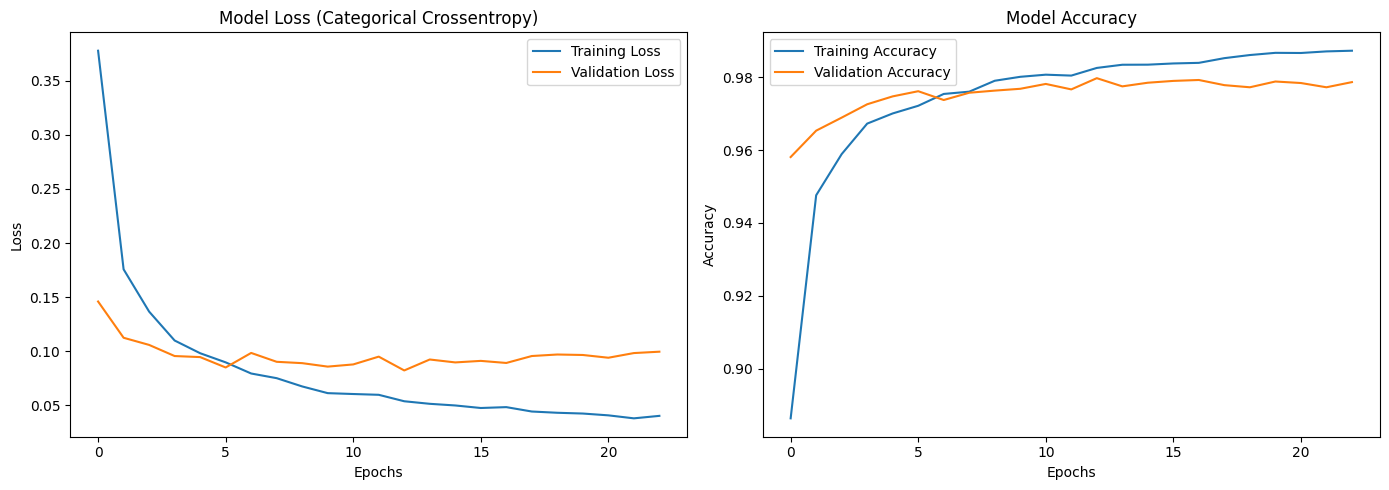

In [ ]:
class AdvertisingMLP:
  def __init__(self, file_path):
    self.file_path = file_path
    self.df = None
    self.X_train = None
    self.X_test = None
    self.y_train = None
    self.y_test = None
    self.scaler = StandardScaler()

  def load_data(self):
    try:
      self.df = pd.read_csv(self.file_path)
      print(f"Data loaded successfully. Shape: {self.df.shape}")
      return self.df
    except FileNotFoundError:
      print(f"File {self.file_path} not found.")
      return None

  def perform_eda(self):
    print("\n--- (a) Exploratory Data Analysis ---")
    print(self.df.describe())

    # 1. Correlation Heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(self.df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Feature Correlation Matrix')
    plt.show()

    # 2. Pairplot to see relationships
    sns.pairplot(self.df, diag_kind='kde')
    plt.suptitle('Pairplot of Features', y=1.02)
    plt.show()
    print("EDA Visualizations generated.")

  def preprocess(self):
    print("\n--- (b) Preprocessing ---")

    # 1. Convert Sales to Binary Class (High vs Low)
    threshold = self.df['Sales'].median()
    self.df['High_Sales'] = (self.df['Sales'] > threshold).astype(int)

    print(f"Converted 'Sales' to Binary 'High_Sales'. Threshold: {threshold}")
    print(f"Class Distribution:\n{self.df['High_Sales'].value_counts()}")

    # 2. Define Features (X) and Target (y)
    X = self.df.drop(['Sales', 'High_Sales'], axis=1)
    y = self.df['High_Sales']

    # 3. Train-Test Split
    self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    print("Data split into Train and Test sets.")

  def build_mlp_model(self, input_dim):
    model = keras.Sequential([
      layers.Dense(32, activation='relu', input_shape=(input_dim,)),
      layers.Dropout(0.1),
      layers.Dense(16, activation='relu'),
      layers.Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

  def evaluate_experiment(self, scale_data=False):
    status = "WITH SCALING" if scale_data else "WITHOUT SCALING"
    print(f"\n--- Running Experiment: {status} ---")

    # Prepare data for this run
    if scale_data:
      # Fit on Train, Transform on Test
      X_train_run = self.scaler.fit_transform(self.X_train)
      X_test_run = self.scaler.transform(self.X_test)
    else:
      # Use raw data
      X_train_run = self.X_train
      X_test_run = self.X_test

    # Build Model
    model = self.build_mlp_model(input_dim=X_train_run.shape[1])

    # Train
    early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    history = model.fit(
      X_train_run, self.y_train,
      validation_split=0.2,
      epochs=50,
      batch_size=16,
      callbacks=[early_stopping],
      verbose=0
    )

    # (e) Predict for test data
    y_pred_prob = model.predict(X_test_run)
    y_pred = (y_pred_prob > 0.5).astype(int).flatten()

    # Metrics
    acc = accuracy_score(self.y_test, y_pred)
    cm = confusion_matrix(self.y_test, y_pred)

    print(f"Accuracy ({status}): {acc:.4f}")
    print(f"Confusion Matrix:\n{cm}")

    return history, acc, y_pred, y_pred_prob

  def run_pipeline(self):
    # 1. Load
    if self.load_data() is None: return

    # 2. EDA
    self.perform_eda()

    # 3. Preprocess
    self.preprocess()

    # 4. Experiment 1: WITHOUT SCALING
    _, acc_unscaled, _, _ = self.evaluate_experiment(scale_data=False)

    # 5. Experiment 2: WITH SCALING
    history_scaled, acc_scaled, y_pred, y_prob = self.evaluate_experiment(scale_data=True)

    print("\n--- Final Comparison ---")
    print(f"Accuracy Unscaled: {acc_unscaled:.4f}")
    print(f"Accuracy Scaled:   {acc_scaled:.4f}")
    if acc_scaled > acc_unscaled:
      print("Scaling IMPROVED performance.")
    else:
      print("Scaling had neutral/negative impact (dataset might be simple).")

    # Visualizing the Training of the Scaled Model
    self.plot_history(history_scaled)

    # Show Predictions
    self.show_predictions(y_pred, y_prob)

  def plot_history(self, history):
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    epochs = range(len(loss))

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label='Training Loss')
    plt.plot(epochs, val_loss, label='Validation Loss')
    plt.title('Loss (Scaled Data)')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, acc, label='Training Accuracy')
    plt.plot(epochs, val_acc, label='Validation Accuracy')
    plt.title('Accuracy (Scaled Data)')
    plt.legend()
    plt.show()

  def show_predictions(self, y_pred, y_prob):
    print("\n--- (e) Prediction Snapshot (Test Data) ---")
    results = pd.DataFrame({
      'Actual': self.y_test.values,
      'Predicted': y_pred,
      'Probability': y_prob.flatten().round(4)
    })
    print(results.head(10))

# --- Execution ---
if __name__ == "__main__":
  # Ensure 'advertising.csv' is in the directory
  pipeline = AdvertisingMLP(file_path='advertising.csv')
  pipeline.run_pipeline()